<a href="https://colab.research.google.com/github/40824226-sys/try_/blob/main/%E4%BD%9C%E5%93%812_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 水果好壞判別

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dir_path='/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset'

In [ ]:
os.listdir(dir_path) #蘋果179(124,55) 草莓264(220,44) 香蕉123(33,90)

['Apple', 'Strawberry', 'Banana']

In [ ]:
Apple_path=os.path.join(dir_path,'Apple')
Strawberry_path=os.path.join(dir_path,'Strawberry')
Banana_path=os.path.join(dir_path,'Banana')
print(f'蘋果:{os.listdir(Apple_path)}')
print(f'香蕉:{os.listdir(Banana_path)}')
print(f'草莓:{os.listdir(Strawberry_path)}')



蘋果:['Fresh', 'Rotten']
香蕉:['Fresh', 'Rotten']
草莓:['Fresh', 'Rotten']


In [ ]:
imgpaths=[] #圖片路徑
labels=[]  #標籤名稱
fruitname_dir=os.listdir(dir_path)     #列出 'Apple','Strawberry','Banana'
for i in fruitname_dir:
  fruit_dir=os.path.join(dir_path,i)   #結合路徑
  if os.path.isdir(fruit_dir):
    fruit_list=os.listdir(fruit_dir)  #列出 'Fresh','Rotten'
    for j in fruit_list:
      FreshRotten_dir=os.path.join(fruit_dir,j)      #結合路徑
      if os.path.isdir(FreshRotten_dir):
        for k in os.listdir(FreshRotten_dir):
          if k.endswith('.jpg',) or k.endswith('.png') or k.endswith('.jpeg'):
            img_path=os.path.join(FreshRotten_dir,k) #結合路徑
            imgpaths.append(img_path)
            labels.append(j)


In [ ]:
print(len(imgpaths))
print(len(labels))
print(imgpaths)
print(labels)

529
529
['/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (87).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (77).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (78).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (86).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (73).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (56).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (53).jpg', '/content/drive/MyDrive/py報告/archive/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fres

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
x=np.array(imgpaths)
y=np.array(labels)

In [ ]:
#測試20%
x_train_temp,x_test,y_train_temp,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
#訓練70% 驗證10%
x_train,x_val,y_train,y_val = train_test_split(x_train_temp,y_train_temp,test_size=0.125,random_state=42,stratify=y_train_temp) #stratify:確保各類別比例一致 random_state=42:固定結果

In [ ]:
print(len(x_train))
print(len(x_val))
print(len(x_test))

370
53
106


In [ ]:
IMG_SIZE=100 #定義圖片縮放大小
def fix_img(image_paths):
  images=[]
  for path in image_paths:
    img=cv2.imread(path)
    if img is not None:
      img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
      img=cv2.resize(img,(IMG_SIZE, IMG_SIZE))
      img=img/255.0
      images.append(img)
  return np.array(images)

x_train_images = fix_img(x_train)
x_val_images = fix_img(x_val)
x_test_images = fix_img(x_test)




In [ ]:


#將標籤字串轉換為整數  'Fresh'=0, 'Rotten'=1
label_encoder=LabelEncoder()
y_train_encoded=label_encoder.fit_transform(y_train)
y_val_encoded=label_encoder.transform(y_val)
y_test_encoded=label_encoder.transform(y_test)

#轉換為獨熱編碼
num_classes=len(np.unique(labels))
y_train_onehot=to_categorical(y_train_encoded, num_classes)
y_val_onehot=to_categorical(y_val_encoded, num_classes)
y_test_onehot=to_categorical(y_test_encoded, num_classes)

print(num_classes)



2


In [ ]:

#下載開源的台北黑體並設定給Matplotlib
!wget -O font.ttf https://github.com/notofonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontEntry, fontManager

#將下載的字體加入Matplotlib管理器中
fe = FontEntry(fname='font.ttf', name='NotoSansCJKtc')
fontManager.ttflist.insert(0,fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams['axes.unicode_minus'] = False

print("字體設定完成！")


--2026-05-19 06:52:00--  https://github.com/notofonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf [following]
--2026-05-19 06:52:00--  https://raw.githubusercontent.com/notofonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16435884 (16M) [application/octet-stream]
Saving to: ‘font.ttf’

font.ttf            100%[===================>]  15.67M  --.-KB/s    in 0.06s   

2026-05

In [ ]:
#模型
model=Sequential()
#第一層卷積與池化
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(IMG_SIZE, IMG_SIZE, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#第二層卷積與池化
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#第三層卷積與池化
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#刪除層
model.add(Dropout(0.2))
#平坦層
model.add(Flatten())
#全連接層
model.add(Dense(units=128, activation='relu'))
#全連接層(輸出層)
model.add(Dense(units=2, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,034 (6.61 MB)

 Trainable params: 1,732,034 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - accuracy: 0.6000 - loss: 0.7086 - val_accuracy: 0.8679 - val_loss: 0.4625
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8054 - loss: 0.4566 - val_accuracy: 0.9623 - val_loss: 0.2267
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8514 - loss: 0.3461 - val_accuracy: 0.9811 - val_loss: 0.1852
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9027 - loss: 0.2453 - val_accuracy: 0.8491 - val_loss: 0.2256
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9081 - loss: 0.2142 - val_accuracy: 0.9811 - val_loss: 0.1386
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9351 - loss: 0.1665 - val_accuracy: 0.9623 - val_loss: 0.1284
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9378 - loss: 0.1390 - val_accuracy: 0.9811 - val_loss: 0.1160
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9459 - loss: 0.1316 - val_accuracy: 0.9623 - 

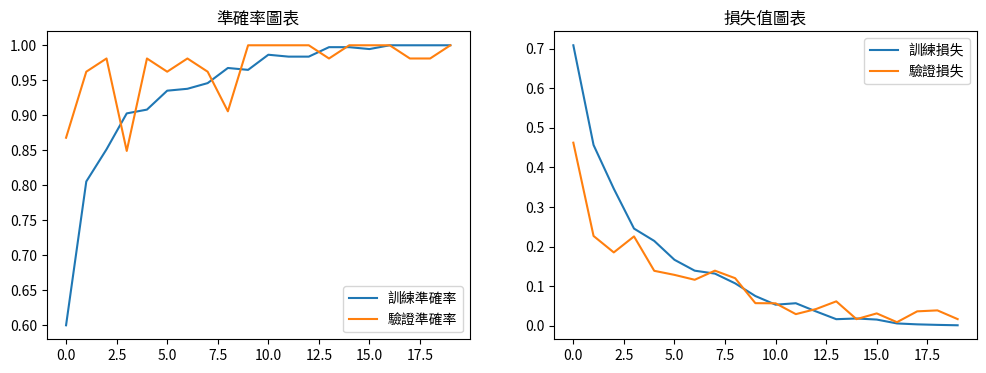

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9340 - loss: 0.4006
測試集準確率:93.40%
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
預測結果:Fresh,真實結果:Fresh


In [ ]:
#編譯模型
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

#印出神經網路模型架構表
model.summary()

#使用EarlyStopping避免過擬合(當驗證集損失值不再下降時停止)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#訓練模型
history = model.fit(x_train_images, y_train_onehot,epochs=20,batch_size=32,
                    validation_data=(x_val_images, y_val_onehot),callbacks=[early_stop])


#繪製準確率圖表
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='訓練準確率')
plt.plot(history.history['val_accuracy'], label='驗證準確率')
plt.title('準確率圖表')
plt.legend()

#繪製損失函數圖表
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='訓練損失')
plt.plot(history.history['val_loss'], label='驗證損失')
plt.title('損失值圖表')
plt.legend()
plt.show()

#預測
loss,acc = model.evaluate(x_test_images,y_test_onehot)
print(f"測試集準確率:{acc*100:.2f}%")

#預測測試圖第1張圖片
prediction = model.predict(x_test_images[:1])
predicted_class = label_encoder.inverse_transform([np.argmax(prediction)])
print(f"預測結果:{predicted_class[0]},真實結果:{y_test[0]}")
